## Encoding into k and k-1 dummy variables

More generally, a categorical variable should be encoded by creating k-1 binary variables, where k is the number of distinct categories. 
Most machine learning algorithms, consider the entire data set while being fit. Therefore, encoding categorical variables into k - 1 binary variables, is better, as it avoids introducing redundant information.

It is possible to decide to encode only the top X (10?, 20?, 50? most frequent values) in case the number of columns generated will make the transformation not efficient.

### Encoding into k variables

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.preprocessing import OneHotEncoder

In [ ]:
data = pd.read_csv('titanic.csv',
                   usecols=['sex', 'embarked', 'cabin', 'survived'])
data.head()

,survived,sex,cabin,embarked
0,1,female,B5,S
1,1,male,C22,S
2,0,female,C22,S
3,0,male,C22,S
4,0,female,C22,S


In [ ]:
data['cabin_location']=data['cabin'].str[0]

In [ ]:
for i in data.columns:
  print(i)
  print(data[i].unique(), '\n')

survived
[1 0] 

sex
['female' 'male'] 

cabin
['B5' 'C22' 'E12' 'D7' 'A36' 'C101' nan 'C62' 'B35' 'A23' 'B58' 'D15' 'C6'
 'D35' 'C148' 'C97' 'B49' 'C99' 'C52' 'T' 'A31' 'C7' 'C103' 'D22' 'E33'
 'A21' 'B10' 'B4' 'E40' 'B38' 'E24' 'B51' 'B96' 'C46' 'E31' 'E8' 'B61'
 'B77' 'A9' 'C89' 'A14' 'E58' 'E49' 'E52' 'E45' 'B22' 'B26' 'C85' 'E17'
 'B71' 'B20' 'A34' 'C86' 'A16' 'A20' 'A18' 'C54' 'C45' 'D20' 'A29' 'C95'
 'E25' 'C111' 'C23' 'E36' 'D34' 'D40' 'B39' 'B41' 'B102' 'C123' 'E63'
 'C130' 'B86' 'C92' 'A5' 'C51' 'B42' 'C91' 'C125' 'D10' 'B82' 'E50' 'D33'
 'C83' 'B94' 'D49' 'D45' 'B69' 'B11' 'E46' 'C39' 'B18' 'D11' 'C93' 'B28'
 'C49' 'B52' 'E60' 'C132' 'B37' 'D21' 'D19' 'C124' 'D17' 'B101' 'D28' 'D6'
 'D9' 'B80' 'C106' 'B79' 'C47' 'D30' 'C90' 'E38' 'C78' 'C30' 'C118' 'D36'
 'D48' 'D47' 'C105' 'B36' 'B30' 'D43' 'B24' 'C2' 'C65' 'B73' 'C104' 'C110'
 'C50' 'B3' 'A24' 'A32' 'A11' 'A10' 'B57' 'C28' 'E44' 'A26' 'A6' 'A7'
 'C31' 'A19' 'B45' 'E34' 'B78' 'B50' 'C87' 'C116' 'C55' 'D50' 'E68' 'E67'
 'C12

In [ ]:
tmp = pd.get_dummies(data['sex'])

tmp.head()

,female,male
0,1,0
1,0,1
2,1,0
3,0,1
4,1,0


In [ ]:
pd.concat([data['sex'],
           pd.get_dummies(data['sex'])], axis=1).head()

,sex,female,male
0,female,1,0
1,male,0,1
2,female,1,0
3,male,0,1
4,female,1,0


In [ ]:
tmp= pd.concat([data,
           pd.get_dummies(data)], axis=1).head()

In [ ]:
tmp

,survived,sex,cabin,embarked,cabin_location,survived,sex_female,sex_male,cabin_A10,cabin_A11,cabin_A14,cabin_A16,cabin_A18,cabin_A19,cabin_A20,cabin_A21,cabin_A23,cabin_A24,cabin_A26,cabin_A29,cabin_A31,cabin_A32,cabin_A34,cabin_A36,cabin_A5,cabin_A6,cabin_A7,cabin_A9,cabin_B10,cabin_B101,cabin_B102,cabin_B11,cabin_B18,cabin_B19,cabin_B20,cabin_B22,cabin_B24,cabin_B26,cabin_B28,cabin_B3,...,cabin_E24,cabin_E25,cabin_E31,cabin_E33,cabin_E34,cabin_E36,cabin_E38,cabin_E39,cabin_E40,cabin_E44,cabin_E45,cabin_E46,cabin_E49,cabin_E50,cabin_E52,cabin_E58,cabin_E60,cabin_E63,cabin_E67,cabin_E68,cabin_E77,cabin_E8,cabin_F,cabin_F2,cabin_F33,cabin_F38,cabin_F4,cabin_G6,cabin_T,embarked_C,embarked_Q,embarked_S,cabin_location_A,cabin_location_B,cabin_location_C,cabin_location_D,cabin_location_E,cabin_location_F,cabin_location_G,cabin_location_T
0,1,female,B5,S,B,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
1,1,male,C22,S,C,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
2,0,female,C22,S,C,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
3,0,male,C22,S,C,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
4,0,female,C22,S,C,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0


### Encoding into k-1 variables

In [ ]:
tmp = pd.get_dummies(data['sex'], drop_first=True)

In [ ]:
tmp

,male
0,0
1,1
2,0
3,1
4,0
...,...
1304,0
1305,0
1306,1
1307,1


In [ ]:
pd.concat([data['sex'],
           pd.get_dummies(data['sex'], drop_first=True)], axis=1).head()

,sex,male
0,female,0
1,male,1
2,female,0
3,male,1
4,female,0


In [ ]:
pd.get_dummies(data['embarked'])

,C,Q,S
0,0,0,1
1,0,0,1
2,0,0,1
3,0,0,1
4,0,0,1
...,...,...,...
1304,1,0,0
1305,1,0,0
1306,1,0,0
1307,1,0,0


In [ ]:
pd.get_dummies(data['embarked'], drop_first=True)

,Q,S
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1
...,...,...
1304,0,0
1305,0,0
1306,0,0
1307,0,0


In [ ]:
data['cabin_location'].isnull().sum()

1014

In [ ]:
pd.get_dummies(data['cabin_location'], drop_first=True, dummy_na=True).head(10)

,B,C,D,E,F,G,T,NaN
0,1,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0
5,0,0,0,1,0,0,0,0
6,0,0,1,0,0,0,0,0
7,0,0,0,0,0,0,0,0
8,0,1,0,0,0,0,0,0
9,0,0,0,0,0,0,0,1


#### Using sklearn

In [ ]:
# we create and train the encoder

encoder = OneHotEncoder(categories='auto',
                       drop='first', # to return k-1, use drop=false to return k dummies
                       sparse=False,
                       handle_unknown='error')

encoder.fit(data[['sex']])

OneHotEncoder(categories='auto', drop='first', dtype=<class 'numpy.float64'>,
              handle_unknown='error', sparse=False)

# Integer Encoding

Integer encoding consist in replacing the categories by digits from 1 to n (or 0 to n-1, depending the implementation), where n is the number of distinct categories of the variable.

The numbers are assigned arbitrarily.

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
data['cabin'].isnull().sum()

1014

In [ ]:
data['cabin'].value_counts()

F       8
C23     6
G6      5
B57     5
D       4
       ..
E49     1
C130    1
C28     1
C95     1
C47     1
Name: cabin, Length: 181, dtype: int64

In [ ]:
ordinal_mapping = {
    k: i
    for i, k in enumerate(data['cabin'].unique())
}

ordinal_mapping

{'A10': 137,
 'A11': 136,
 'A14': 40,
 'A16': 53,
 'A18': 55,
 'A19': 145,
 'A20': 54,
 'A21': 25,
 'A23': 9,
 'A24': 134,
 'A26': 141,
 'A29': 59,
 'A31': 20,
 'A32': 135,
 'A34': 51,
 'A36': 4,
 'A5': 75,
 'A6': 142,
 'A7': 143,
 'A9': 38,
 'B10': 26,
 'B101': 105,
 'B102': 69,
 'B11': 89,
 'B18': 92,
 'B19': 160,
 'B20': 50,
 'B22': 45,
 'B24': 126,
 'B26': 46,
 'B28': 95,
 'B3': 133,
 'B30': 124,
 'B35': 8,
 'B36': 123,
 'B37': 100,
 'B38': 29,
 'B39': 67,
 'B4': 27,
 'B41': 68,
 'B42': 77,
 'B45': 146,
 'B49': 16,
 'B5': 0,
 'B50': 149,
 'B51': 31,
 'B52': 97,
 'B57': 138,
 'B58': 10,
 'B61': 36,
 'B69': 88,
 'B71': 49,
 'B73': 129,
 'B77': 37,
 'B78': 148,
 'B79': 111,
 'B80': 109,
 'B82': 81,
 'B86': 73,
 'B94': 85,
 'B96': 32,
 'C101': 5,
 'C103': 22,
 'C104': 130,
 'C105': 122,
 'C106': 110,
 'C110': 131,
 'C111': 62,
 'C116': 151,
 'C118': 118,
 'C123': 70,
 'C124': 103,
 'C125': 79,
 'C126': 156,
 'C128': 167,
 'C130': 72,
 'C132': 99,
 'C148': 14,
 'C2': 127,
 'C22': 1,
 'C

In [ ]:
data['cabin_om'] = data['cabin'].map(ordinal_mapping)

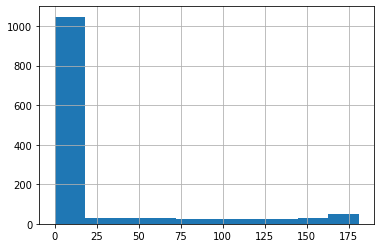

In [ ]:
data['cabin_om'].hist()

In [ ]:
le = LabelEncoder()

In [ ]:
le.fit(data['cabin'].dropna()) #LabelEncoder's target are class labels, nan are not 

LabelEncoder()

In [ ]:
le.transform(data['cabin'].dropna()) 

array([ 43,  79,  79,  79,  79, 149, 145,  15,  61,  97,  97,  33,   8,
        48,  48, 120,  96, 131, 131,  77, 115,  42,  42, 116,  92, 180,
        12, 100,  62, 125, 155,   7,  20,  38,  61, 120, 160,  36, 152,
        45,  45,  45,  60,  60,  60,  60,  87,  87, 154, 154, 173, 173,
        49,  53,  19, 155, 109, 109,   2, 167, 164, 166, 162,  61,  27,
        27,  29, 106, 106, 151,  51,  51,  26,  26,  14,  14,  14, 107,
        48, 107,   3,   6,   4,  94,  86, 123,  11, 114, 153,  67,  80,
        80,  80,  80,  80,  80, 157, 130, 135,  37,  39,  39,  22,  70,
        70, 169,  75,  58, 112, 112,  16,  91,  40, 111,  72, 118, 118,
        57, 165, 165, 129, 129, 105, 105,  59, 141, 137,  94,  50,  50,
        23, 163,  85,  24,  24, 119, 113, 113,  30,  89,  46, 168,  76,
        35, 124, 124, 122, 122,  71, 121,  21, 127, 127, 144, 146,  56,
        43,  65,  55,  88, 128, 128, 110,  96, 163, 153, 158, 102, 102,
       102, 102,  82,  69, 132, 132, 140, 139,  64,  34,  32, 13

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
enc = OrdinalEncoder()

In [ ]:
enc.fit(data[['sex','cabin']].dropna())

OrdinalEncoder(categories='auto', dtype=<class 'numpy.float64'>)

In [ ]:
enc.transform(data[['sex','cabin']].dropna())

array([[  0.,  43.],
       [  1.,  79.],
       [  0.,  79.],
       [  1.,  79.],
       [  0.,  79.],
       [  1., 149.],
       [  0., 145.],
       [  1.,  15.],
       [  0.,  61.],
       [  1.,  97.],
       [  0.,  97.],
       [  0.,  33.],
       [  1.,   8.],
       [  1.,  48.],
       [  0.,  48.],
       [  0., 120.],
       [  1.,  96.],
       [  1., 131.],
       [  0., 131.],
       [  1.,  77.],
       [  0., 115.],
       [  1.,  42.],
       [  0.,  42.],
       [  0., 116.],
       [  1.,  92.],
       [  1., 180.],
       [  1.,  12.],
       [  0., 100.],
       [  0.,  62.],
       [  1., 125.],
       [  0., 155.],
       [  1.,   7.],
       [  1.,  20.],
       [  0.,  38.],
       [  0.,  61.],
       [  0., 120.],
       [  0., 160.],
       [  1.,  36.],
       [  1., 152.],
       [  1.,  45.],
       [  0.,  45.],
       [  1.,  45.],
       [  1.,  60.],
       [  0.,  60.],
       [  1.,  60.],
       [  0.,  60.],
       [  1.,  87.],
       [  0.,

## Count or frequency encoding

We can replace the category by the frequency -or percentage- of observations in the dataset. These techniques capture the representation of each label in a dataset, but the encoding may not necessarily be predictive of the outcome. 

Note that if 2 different categories appear the same amount of times in the dataset, that is, they appear in the same number of observations, they will be replaced by the same number: may lose valuable information

In [ ]:
count_map = data['cabin_location'].value_counts().to_dict()

In [ ]:
count_map

{'C': 270, 'Q': 123, 'S': 914}

In [ ]:
data['cabin_location_count']=data['cabin_location'].map(count_map)

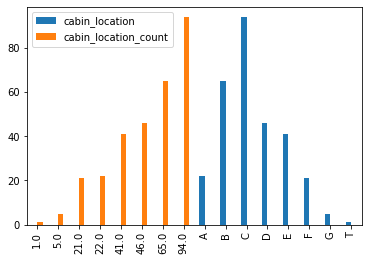

In [ ]:


data[["cabin_location","cabin_location_count"]].apply(pd.value_counts).plot(kind='bar')


###  Computing the frequency

In [ ]:
data['embarked'].isnull().sum()

2

In [ ]:
tmp = {i:v/len(data['embarked']) for i,v in count_map.items()}

In [ ]:
tmp

{'C': 0.20626432391138275, 'Q': 0.09396485867074103, 'S': 0.6982429335370511}

In [ ]:
data['embarked_freq']=data['embarked'].map(tmp)

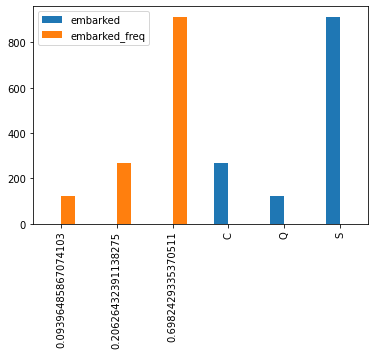

In [ ]:
data[["embarked","embarked_freq"]].apply(pd.value_counts).plot(kind='bar')